# Realtime CTR Throughput and Scalability Analysis

This notebook evaluates the throughput, Redis write cost, processing completeness, and local parallel scaling of the realtime CTR Flink job.

All five configurations process the same deterministic backlog of 200,000 impressions and 4,126 clicks. The two independent variables are Flink parallelism (`1`, `2`, or `4`) and Redis persistence strategy (`per-event` or `periodic` coalescing). This design supports direct comparisons of parallelism at a fixed Redis strategy and Redis persistence at a fixed parallelism.

In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the ctx-ctr repository")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROJECT_ROOT

PosixPath('/Users/itonkdong/Work/Fax/RNMP/ctx-ctr')

## Experimental design

The `run_id` identifies the saved artifact and has no ordinal analytical meaning. `parallelism` is the number of Flink operator subtasks. `redis_strategy` describes whether every valid event causes a Redis write or whether keyed updates are coalesced and flushed after 500 ms or 100 updates.

In [3]:
EXPERIMENTS = [
    {
        "run_id": 1,
        "configuration": "P1 / per-event Redis",
        "short_label": "P1 / per-event",
        "parallelism": 1,
        "redis_strategy": "Per event",
        "path": Path("experiments/results/20260725_110445_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "run_id": 2,
        "configuration": "P2 / per-event Redis",
        "short_label": "P2 / per-event",
        "parallelism": 2,
        "redis_strategy": "Per event",
        "path": Path("experiments/results/20260725_110655_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "run_id": 6,
        "configuration": "P1 / periodic Redis",
        "short_label": "P1 / periodic",
        "parallelism": 1,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_170324_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "run_id": 4,
        "configuration": "P2 / periodic Redis",
        "short_label": "P2 / periodic",
        "parallelism": 2,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_165139_realtime_ctr_performance_baseline/result.json"),
    },
    {
        "run_id": 5,
        "configuration": "P4 / periodic Redis",
        "short_label": "P4 / periodic",
        "parallelism": 4,
        "redis_strategy": "500 ms or 100 updates",
        "path": Path("experiments/results/20260719_170150_realtime_ctr_performance_baseline/result.json"),
    },
]

for experiment in EXPERIMENTS:
    absolute_path = PROJECT_ROOT / experiment["path"]
    if not absolute_path.is_file():
        raise FileNotFoundError(f"Missing experiment artifact: {absolute_path}")

pd.DataFrame(EXPERIMENTS)[["run_id", "configuration", "parallelism", "redis_strategy", "path"]]

,run_id,configuration,parallelism,redis_strategy,path
0,1,P1 / per-event Redis,1,Per event,experiments/results/20260725_110445_realtime_c...
1,2,P2 / per-event Redis,2,Per event,experiments/results/20260725_110655_realtime_c...
2,6,P1 / periodic Redis,1,500 ms or 100 updates,experiments/results/20260719_170324_realtime_c...
3,4,P2 / periodic Redis,2,500 ms or 100 updates,experiments/results/20260719_165139_realtime_c...
4,5,P4 / periodic Redis,4,500 ms or 100 updates,experiments/results/20260719_170150_realtime_c...


## Metric definitions

The tables use the following fields:

| Field | Meaning |
|---|---|
| `run_id` | Identifier of the saved experiment artifact; it is not a performance ranking. |
| `configuration` / `short_label` | Human-readable combination of Flink parallelism and Redis persistence strategy. |
| `parallelism` | Number of parallel Flink subtasks assigned to the keyed CTR operator. |
| `redis_strategy` | `Per event` writes every valid update immediately; periodic mode coalesces keyed updates for up to 500 ms or 100 updates. |
| `produced_events` | Total Kafka events created by the producer: impressions plus sampled clicks. |
| `processed_events` | Events reported as consumed by all realtime CTR subtasks at experiment completion. |
| `valid_events` | Processed events accepted by the CTR update service. |
| `dead_letters` | Invalid events rejected and sent to the Kafka dead-letter topic. |
| `elapsed_seconds` | Largest elapsed processor time among subtasks; this is the parallel job's completion time. |
| `full_window_records` | Number of complete 5,000-event metric windows across all subtasks. More full windows make the active-rate estimate less sensitive to startup and shutdown. |
| `end_to_end_eps` | `processed_events / elapsed_seconds`; includes startup and the trailing partial window. |
| `full_window_eps` | Sum of each concurrently running subtask's mean rate over complete 5,000-event windows. This estimates active processing capacity. |
| `post_warmup_eps` | Same as `full_window_eps`, excluding each subtask's first complete window. This estimates steady-state capacity after warmup. |
| `redis_flushes` | Actual Redis write operations emitted by the processor. |
| `redis_updates_flushed` | Valid CTR updates represented by the Redis writes. This should equal `valid_events` after a complete drain. |
| `redis_updates_coalesced` | Updates represented by an existing flush rather than an additional Redis write. |
| `updates_per_redis_write` | `valid_events / redis_flushes`; higher values mean more write coalescing. |
| `redis_write_reduction_pct` | Percentage of writes avoided relative to one Redis write per valid event. |
| `redis_impression_delta` / `redis_click_delta` | Change in aggregate Redis bucket counts during the experiment. |
| `gates_passed` | Whether the experiment's configured correctness gates passed. |
| `all_events_processed` | Whether producer and processor event totals match exactly. |
| `all_updates_flushed` | Whether all valid processor updates are represented in Redis flush metrics. |
| `status` | `PASS` only when counts reconcile, gates pass, and no dead letters are produced. |

For parallel configurations, full-window and post-warmup rates are summed across subtasks because those subtasks execute concurrently. The three throughput views answer different questions: end-to-end rate describes observed completion speed, full-window rate describes active capacity, and post-warmup rate reduces startup influence.

In [4]:
def load_result(relative_path: Path) -> dict:
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

def processor_records(payload: dict) -> pd.DataFrame:
    records = payload["metrics"]["processor_metrics"]["realtime_ctr"]["records"]
    frame = pd.DataFrame(records).copy()
    if "subtask_index" not in frame:
        frame["subtask_index"] = 0
    frame["subtask_index"] = frame["subtask_index"].fillna(0).astype(int)
    frame["record_index"] = frame.groupby("subtask_index").cumcount() + 1
    return frame

def full_window_rates(records: pd.DataFrame, drop_warmup: bool = False) -> list[float]:
    rates: list[float] = []
    for _, subtask in records.groupby("subtask_index"):
        max_window = subtask["window_events"].max()
        full_windows = subtask[subtask["window_events"] == max_window]
        if drop_warmup and len(full_windows) > 1:
            full_windows = full_windows.iloc[1:]
        rates.append(float(full_windows["window_events_per_second"].mean()))
    return rates

def full_window_count(records: pd.DataFrame) -> int:
    count = 0
    for _, subtask in records.groupby("subtask_index"):
        count += int((subtask["window_events"] == subtask["window_events"].max()).sum())
    return count

def summarize_experiment(experiment: dict, payload: dict) -> dict:
    records = processor_records(payload)
    final_records = records.groupby("subtask_index", as_index=False).tail(1)
    producer = payload["metrics"]["producer"]
    delta = payload["metrics"]["statistics"]["delta"]
    gates = payload["metrics"].get("success_gates", {})

    processed_events = int(final_records["processed_events"].sum())
    valid_events = int(final_records["valid_events"].sum())
    elapsed_seconds = float(final_records["elapsed_seconds"].max())
    has_flush_metrics = "redis_flushes" in final_records.columns
    redis_flushes = (
        int(final_records["redis_flushes"].sum())
        if has_flush_metrics
        else valid_events
    )
    redis_updates_flushed = (
        int(final_records["redis_updates_flushed"].sum())
        if has_flush_metrics
        else valid_events
    )
    redis_updates_coalesced = (
        int(final_records["redis_updates_coalesced"].sum())
        if has_flush_metrics
        else 0
    )

    return {
        "run_id": experiment["run_id"],
        "configuration": experiment["configuration"],
        "short_label": experiment["short_label"],
        "parallelism": experiment["parallelism"],
        "redis_strategy": experiment["redis_strategy"],
        "produced_events": int(producer["total_events"]),
        "processed_events": processed_events,
        "valid_events": valid_events,
        "dead_letters": int(final_records["dead_letters"].sum()),
        "elapsed_seconds": elapsed_seconds,
        "end_to_end_eps": processed_events / elapsed_seconds,
        "full_window_eps": sum(full_window_rates(records)),
        "post_warmup_eps": sum(full_window_rates(records, drop_warmup=True)),
        "full_window_records": full_window_count(records),
        "redis_flushes": redis_flushes,
        "redis_updates_flushed": redis_updates_flushed,
        "redis_updates_coalesced": redis_updates_coalesced,
        "updates_per_redis_write": valid_events / redis_flushes,
        "redis_write_reduction_pct": 100 * (1 - redis_flushes / valid_events),
        "redis_impression_delta": int(delta["redis_total_impressions"]),
        "redis_click_delta": int(delta["redis_total_clicks"]),
        "gates_passed": bool(gates.get("passed", False)),
        "flush_metrics_source": "Recorded" if has_flush_metrics else "Unavailable",
    }

In [5]:
payloads = {experiment["configuration"]: load_result(experiment["path"]) for experiment in EXPERIMENTS}
records_by_configuration = {
    configuration: processor_records(payload)
    for configuration, payload in payloads.items()
}
summary = pd.DataFrame([
    summarize_experiment(experiment, payloads[experiment["configuration"]])
    for experiment in EXPERIMENTS
]).set_index("configuration")
summary

,run_id,short_label,parallelism,redis_strategy,produced_events,processed_events,valid_events,dead_letters,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,full_window_records,redis_flushes,redis_updates_flushed,redis_updates_coalesced,updates_per_redis_write,redis_write_reduction_pct,redis_impression_delta,redis_click_delta,gates_passed,flush_metrics_source
configuration,,,,,,,,,,,,,,,,,,,,,,
P1 / per-event Redis,1,P1 / per-event,1,Per event,204126,204126,204126,0,61.03,"3,344.85","3,652.30","3,712.19",40,204126,204126,0,1.00,0.00,200000,4126,True,Recorded
P2 / per-event Redis,2,P2 / per-event,2,Per event,204126,204126,204126,0,49.05,"4,161.84","4,798.59","4,932.90",40,204126,204126,0,1.00,0.00,200000,4126,True,Recorded
P1 / periodic Redis,6,P1 / periodic,1,500 ms or 100 updates,204126,204126,204126,0,21.03,"9,706.06","15,591.14","15,944.13",40,1640,204126,202486,124.47,99.20,200000,4126,True,Recorded
P2 / periodic Redis,4,P2 / periodic,2,500 ms or 100 updates,204126,204126,204126,0,19.04,"10,721.85","17,650.58","18,407.77",40,1515,204126,202611,134.74,99.26,200000,4126,True,Recorded
P4 / periodic Redis,5,P4 / periodic,4,500 ms or 100 updates,204126,204126,204126,0,20.04,"10,186.67","18,488.19","20,101.27",38,1279,204126,202847,159.60,99.37,200000,4126,True,Recorded


## Result overview

This table places workload completeness, processor timing, active throughput, and Redis write efficiency side by side.

In [5]:
summary_columns = [

    "parallelism",
    "redis_strategy",
    "produced_events",
    "processed_events",
    "full_window_records",
    "elapsed_seconds",
    "end_to_end_eps",
    "full_window_eps",
    "post_warmup_eps",
    "redis_flushes",
    "updates_per_redis_write",
    "redis_write_reduction_pct",
]
summary[summary_columns].style.format({
    "produced_events": "{:,.0f}",
    "processed_events": "{:,.0f}",
    "full_window_records": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
})

,parallelism,redis_strategy,produced_events,processed_events,full_window_records,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
configuration,,,,,,,,,,,,
P1 / per-event Redis,1,Per event,"204,126","204,126",40,61.03,"3,345","3,652","3,712","204,126",1.0x,0.00%
P2 / per-event Redis,2,Per event,"204,126","204,126",40,49.05,"4,162","4,799","4,933","204,126",1.0x,0.00%
P1 / periodic Redis,1,500 ms or 100 updates,"204,126","204,126",40,21.03,"9,706","15,591","15,944","1,640",124.5x,99.20%
P2 / periodic Redis,2,500 ms or 100 updates,"204,126","204,126",40,19.04,"10,722","17,651","18,408","1,515",134.7x,99.26%
P4 / periodic Redis,4,500 ms or 100 updates,"204,126","204,126",38,20.04,"10,187","18,488","20,101","1,279",159.6x,99.37%


## Throughput comparison

The bar chart compares observed completion rate (`end_to_end_eps`), active processing capacity (`full_window_eps`), and warmed steady-state capacity (`post_warmup_eps`). The dashed line marks the 3,000 events/sec target. The following table reports each rate relative to the P1 per-event reference; a speedup of `1.00x` means equal performance and `2.00x` means twice the reference throughput.

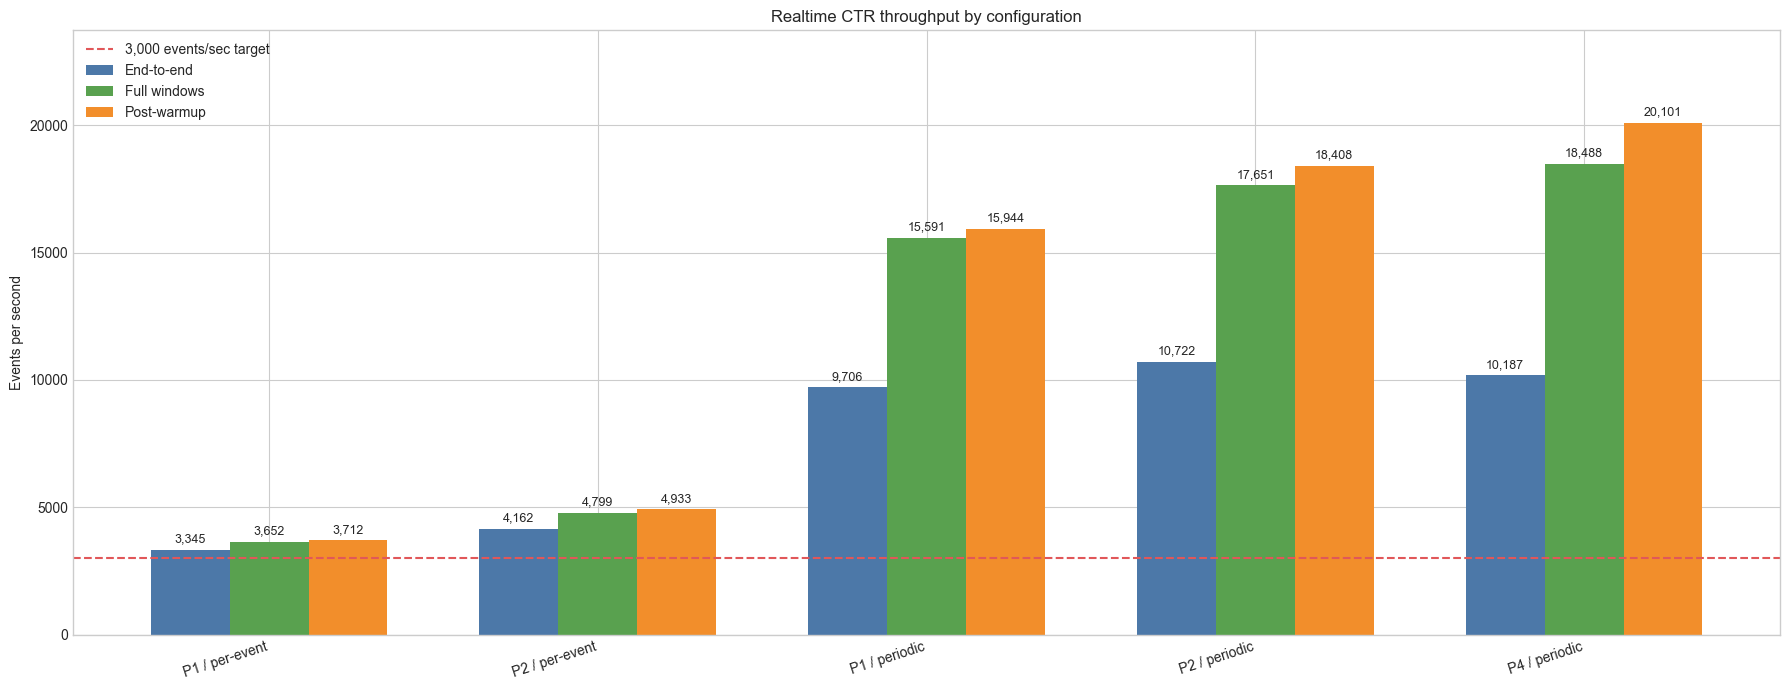

In [6]:
labels = summary["short_label"].tolist()
x = np.arange(len(labels))
width = 0.24
fig, ax = plt.subplots(figsize=(18, 7))
series = [
    ("End-to-end", "end_to_end_eps", "#4C78A8"),
    ("Full windows", "full_window_eps", "#59A14F"),
    ("Post-warmup", "post_warmup_eps", "#F28E2B"),
]
for index, (name, column, color) in enumerate(series):
    bars = ax.bar(x + (index - 1) * width, summary[column], width, label=name, color=color)
    ax.bar_label(bars, labels=[f"{value:,.0f}" for value in summary[column]], padding=3, fontsize=9)
ax.axhline(3_000, color="#E15759", linestyle="--", linewidth=1.5, label="3,000 events/sec target")
ax.set_ylabel("Events per second")
ax.set_title("Realtime CTR throughput by configuration")
ax.set_xticks(x, labels, rotation=18, ha="right")
ax.legend()
ax.set_ylim(0, summary[["end_to_end_eps", "full_window_eps", "post_warmup_eps"]].to_numpy().max() * 1.18)
plt.tight_layout()
plt.show()

In [7]:
reference = summary.iloc[0]
speedups = summary[["short_label", "end_to_end_eps", "full_window_eps", "post_warmup_eps"]].copy()
for column in ("end_to_end_eps", "full_window_eps", "post_warmup_eps"):
    speedups[f"{column}_speedup"] = speedups[column] / reference[column]
speedups[["short_label", "end_to_end_eps_speedup", "full_window_eps_speedup", "post_warmup_eps_speedup"]].style.format({
    "end_to_end_eps_speedup": "{:.2f}x",
    "full_window_eps_speedup": "{:.2f}x",
    "post_warmup_eps_speedup": "{:.2f}x",
})

,short_label,end_to_end_eps_speedup,full_window_eps_speedup,post_warmup_eps_speedup
configuration,,,,
P1 / per-event Redis,P1 / per-event,1.00x,1.00x,1.00x
P2 / per-event Redis,P2 / per-event,1.24x,1.31x,1.33x
P1 / periodic Redis,P1 / periodic,2.90x,4.27x,4.30x
P2 / periodic Redis,P2 / periodic,3.21x,4.83x,4.96x
P4 / periodic Redis,P4 / periodic,3.05x,5.06x,5.41x


## Redis impact at parallelism 2

This comparison holds Flink parallelism and input data constant at P2 and 204,126 total events. The only tested difference is Redis persistence: synchronous per-event writes versus periodic keyed coalescing. The table reports completion time, throughput, actual Redis writes, updates represented per write, and write reduction.

In [8]:
p2_per_event = summary.iloc[1]
p2_periodic = summary.iloc[3]
p2_periodic_records = records_by_configuration[p2_periodic.name]
p2_periodic_final = p2_periodic_records.groupby("subtask_index", as_index=False).tail(1)
subtask_shares = p2_periodic_final.set_index("subtask_index")["processed_events"] / p2_periodic["processed_events"]

comparison_columns = [
    "short_label", "processed_events", "full_window_records", "elapsed_seconds",
    "end_to_end_eps", "full_window_eps", "post_warmup_eps",
    "redis_flushes", "updates_per_redis_write", "redis_write_reduction_pct",
]
display(summary.iloc[[1, 3]][comparison_columns].style.format({
    "processed_events": "{:,.0f}",
    "full_window_records": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

display(Markdown(f"""
### P2 result

- Full-window throughput increased from **{p2_per_event['full_window_eps']:,.0f}** to **{p2_periodic['full_window_eps']:,.0f} events/sec** (**{p2_periodic['full_window_eps'] / p2_per_event['full_window_eps']:.2f}x**).
- Post-warmup throughput increased from **{p2_per_event['post_warmup_eps']:,.0f}** to **{p2_periodic['post_warmup_eps']:,.0f} events/sec** (**{p2_periodic['post_warmup_eps'] / p2_per_event['post_warmup_eps']:.2f}x**).
- End-to-end processor throughput improved **{p2_periodic['end_to_end_eps'] / p2_per_event['end_to_end_eps']:.2f}x** on the same workload.
- Redis writes fell from **{int(p2_per_event['redis_flushes']):,}** to **{int(p2_periodic['redis_flushes']):,}**, eliminating **{p2_periodic['redis_write_reduction_pct']:.2f}%** of writes while preserving all **{int(p2_periodic['processed_events']):,}** updates.
- The two Flink subtasks processed **{subtask_shares.iloc[0]:.1%}** and **{subtask_shares.iloc[1]:.1%}** of events. This is reasonably balanced, though Kafka key/partition distribution still leaves some skew.
- The periodic P2 run exceeds the 3,000 events/sec target by **{p2_periodic['end_to_end_eps'] / 3_000:.2f}x** end to end and **{p2_periodic['full_window_eps'] / 3_000:.2f}x** during full windows.
"""))

,short_label,processed_events,full_window_records,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
configuration,,,,,,,,,,
P2 / per-event Redis,P2 / per-event,"204,126",40,49.05,"4,162","4,799","4,933","204,126",1.0x,0.00%
P2 / periodic Redis,P2 / periodic,"204,126",40,19.04,"10,722","17,651","18,408","1,515",134.7x,99.26%



### P2 result

- Full-window throughput increased from **4,799** to **17,651 events/sec** (**3.68x**).
- Post-warmup throughput increased from **4,933** to **18,408 events/sec** (**3.73x**).
- End-to-end processor throughput improved **2.58x** on the same workload.
- Redis writes fell from **204,126** to **1,515**, eliminating **99.26%** of writes while preserving all **204,126** updates.
- The two Flink subtasks processed **46.9%** and **53.1%** of events. This is reasonably balanced, though Kafka key/partition distribution still leaves some skew.
- The periodic P2 run exceeds the 3,000 events/sec target by **3.57x** end to end and **5.88x** during full windows.


## Redis persistence impact at P1

This second controlled comparison holds the job at one Flink subtask. It tests whether the Redis effect remains when no parallel processing gain is involved. The fields have the same meaning as in the P2 comparison.

In [9]:
p1_per_event = summary.iloc[0]
p1_periodic = summary.iloc[2]
p1_comparison = summary.iloc[[0, 2]][[
    "short_label", "processed_events", "full_window_records", "end_to_end_eps",
    "full_window_eps", "post_warmup_eps", "redis_flushes",
    "updates_per_redis_write", "redis_write_reduction_pct",
]]
display(p1_comparison.style.format({
    "processed_events": "{:,.0f}",
    "full_window_records": "{:,.0f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

display(Markdown(f"""
### P1 result

- Full-window throughput increased from **{p1_per_event['full_window_eps']:,.0f}** to **{p1_periodic['full_window_eps']:,.0f} events/sec** (**{p1_periodic['full_window_eps'] / p1_per_event['full_window_eps']:.2f}x**).
- Post-warmup throughput increased from **{p1_per_event['post_warmup_eps']:,.0f}** to **{p1_periodic['post_warmup_eps']:,.0f} events/sec** (**{p1_periodic['post_warmup_eps'] / p1_per_event['post_warmup_eps']:.2f}x**).
- End-to-end processor throughput improved **{p1_periodic['end_to_end_eps'] / p1_per_event['end_to_end_eps']:.2f}x** on the same workload.
- Periodic persistence represented **{int(p1_periodic['processed_events']):,} valid updates** with **{int(p1_periodic['redis_flushes']):,} Redis writes**, eliminating **{p1_periodic['redis_write_reduction_pct']:.2f}%** of writes.

Because workload and parallelism are fixed, the magnitude of this difference is strong evidence that synchronous Redis I/O limits P1 processing capacity.
"""))

,short_label,processed_events,full_window_records,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,redis_write_reduction_pct
configuration,,,,,,,,,
P1 / per-event Redis,P1 / per-event,"204,126",40,"3,345","3,652","3,712","204,126",1.0x,0.00%
P1 / periodic Redis,P1 / periodic,"204,126",40,"9,706","15,591","15,944","1,640",124.5x,99.20%



### P1 result

- Full-window throughput increased from **3,652** to **15,591 events/sec** (**4.27x**).
- Post-warmup throughput increased from **3,712** to **15,944 events/sec** (**4.30x**).
- End-to-end processor throughput improved **2.90x** on the same workload.
- Periodic persistence represented **204,126 valid updates** with **1,640 Redis writes**, eliminating **99.20%** of writes.

Because workload and parallelism are fixed, the magnitude of this difference is strong evidence that synchronous Redis I/O limits P1 processing capacity.


## Parallel scaling with periodic Redis persistence

This comparison fixes the input data and Redis strategy, then varies Flink parallelism across P1, P2, and P4. `full_window_speedup` and `post_warmup_speedup` are relative to P1 periodic performance. `full_window_efficiency_pct` is speedup divided by parallelism: 100% would indicate ideal linear scaling.

In [10]:
parallel_scaling = summary.iloc[[2, 3, 4]][[
    "short_label", "parallelism", "processed_events", "elapsed_seconds",
    "end_to_end_eps", "full_window_eps", "post_warmup_eps",
    "redis_flushes", "updates_per_redis_write",
]].sort_values("parallelism")
p1_200k = parallel_scaling.iloc[0]
p2_200k = parallel_scaling.iloc[1]
p4_200k = parallel_scaling.iloc[2]
parallel_scaling["full_window_speedup"] = parallel_scaling["full_window_eps"] / p1_200k["full_window_eps"]
parallel_scaling["post_warmup_speedup"] = parallel_scaling["post_warmup_eps"] / p1_200k["post_warmup_eps"]
parallel_scaling["full_window_efficiency_pct"] = 100 * parallel_scaling["full_window_speedup"] / parallel_scaling["parallelism"]
display(parallel_scaling.style.format({
    "processed_events": "{:,.0f}",
    "elapsed_seconds": "{:.2f}",
    "end_to_end_eps": "{:,.0f}",
    "full_window_eps": "{:,.0f}",
    "post_warmup_eps": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "full_window_speedup": "{:.2f}x",
    "post_warmup_speedup": "{:.2f}x",
    "full_window_efficiency_pct": "{:.1f}%",
}))

p4_records = records_by_configuration[summary.index[4]]
p4_final = p4_records.groupby("subtask_index", as_index=False).tail(1).sort_values("subtask_index")
p4_shares = p4_final["processed_events"] / p4_200k["processed_events"]
display(Markdown(f"""
### Scaling result

- P1 to P2 improves full-window throughput by **{100 * (p2_200k['full_window_eps'] / p1_200k['full_window_eps'] - 1):.2f}%**, post-warmup throughput by **{100 * (p2_200k['post_warmup_eps'] / p1_200k['post_warmup_eps'] - 1):.2f}%**, and end-to-end throughput by **{100 * (p2_200k['end_to_end_eps'] / p1_200k['end_to_end_eps'] - 1):.2f}%**.
- P2 to P4 adds only **{100 * (p4_200k['full_window_eps'] / p2_200k['full_window_eps'] - 1):.2f}%** full-window and **{100 * (p4_200k['post_warmup_eps'] / p2_200k['post_warmup_eps'] - 1):.2f}%** post-warmup throughput; end-to-end throughput changes by **{100 * (p4_200k['end_to_end_eps'] / p2_200k['end_to_end_eps'] - 1):+.2f}%**.
- P4 reaches the highest active rate at **{p4_200k['full_window_eps']:,.0f} events/sec**, but P2 has the best end-to-end rate at **{p2_200k['end_to_end_eps']:,.0f} events/sec**.
- Relative to ideal linear scaling from P1, full-window efficiency is **{parallel_scaling.iloc[1]['full_window_efficiency_pct']:.1f}%** at P2 and **{parallel_scaling.iloc[2]['full_window_efficiency_pct']:.1f}%** at P4.
- P4 subtask shares range from **{p4_shares.min():.1%}** to **{p4_shares.max():.1%}**. The modest key/partition skew does not explain the full scaling gap by itself.

On this local machine, P2 is the practical throughput point: P4 consumes twice the processing lanes for a small active-window gain and no end-to-end gain. The measurements are consistent with local resource contention, coordination or serialization overhead, or a shared external I/O limit, but this experiment does not isolate which factor dominates.
"""))

,short_label,parallelism,processed_events,elapsed_seconds,end_to_end_eps,full_window_eps,post_warmup_eps,redis_flushes,updates_per_redis_write,full_window_speedup,post_warmup_speedup,full_window_efficiency_pct
configuration,,,,,,,,,,,,
P1 / periodic Redis,P1 / periodic,1,"204,126",21.03,"9,706","15,591","15,944","1,640",124.5x,1.00x,1.00x,100.0%
P2 / periodic Redis,P2 / periodic,2,"204,126",19.04,"10,722","17,651","18,408","1,515",134.7x,1.13x,1.15x,56.6%
P4 / periodic Redis,P4 / periodic,4,"204,126",20.04,"10,187","18,488","20,101","1,279",159.6x,1.19x,1.26x,29.6%



### Scaling result

- P1 to P2 improves full-window throughput by **13.21%**, post-warmup throughput by **15.45%**, and end-to-end throughput by **10.47%**.
- P2 to P4 adds only **4.75%** full-window and **9.20%** post-warmup throughput; end-to-end throughput changes by **-4.99%**.
- P4 reaches the highest active rate at **18,488 events/sec**, but P2 has the best end-to-end rate at **10,722 events/sec**.
- Relative to ideal linear scaling from P1, full-window efficiency is **56.6%** at P2 and **29.6%** at P4.
- P4 subtask shares range from **23.2%** to **26.7%**. The modest key/partition skew does not explain the full scaling gap by itself.

On this local machine, P2 is the practical throughput point: P4 consumes twice the processing lanes for a small active-window gain and no end-to-end gain. The measurements are consistent with local resource contention, coordination or serialization overhead, or a shared external I/O limit, but this experiment does not isolate which factor dominates.


## Processing windows

Each point is one processor metric record. `record_index` orders records within a subtask and `window_events_per_second` is the rate since that subtask's previous record. Circles represent complete 5,000-event windows; `x` markers represent partial startup or trailing windows and are excluded from the active-capacity averages. Separate lines show whether parallel subtasks behave consistently over time.

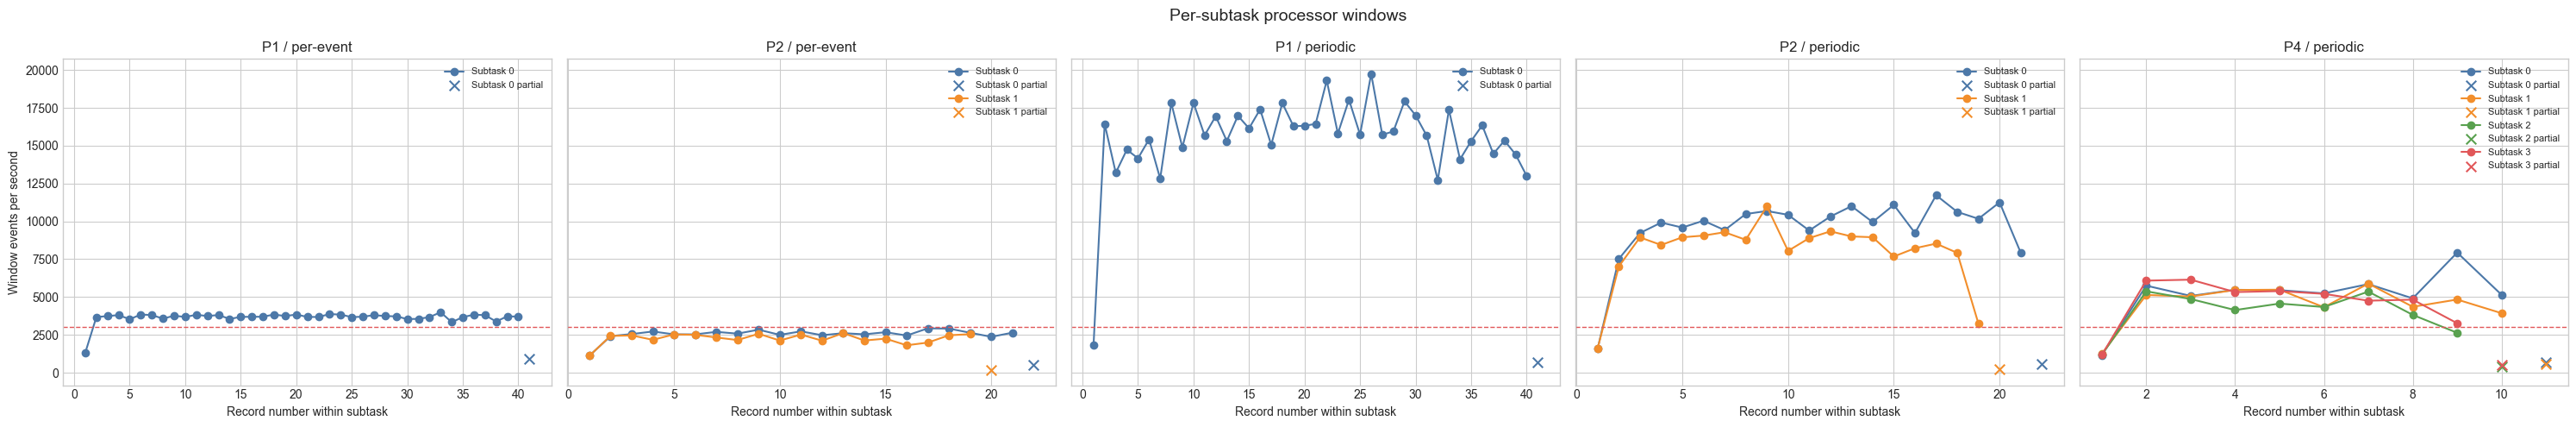

In [11]:
fig, axes = plt.subplots(1, len(EXPERIMENTS), figsize=(30, 5), sharey=True)
colors = ["#4C78A8", "#F28E2B", "#59A14F", "#E15759"]
for ax, experiment in zip(axes, EXPERIMENTS, strict=True):
    records = records_by_configuration[experiment["configuration"]]
    for color, (subtask_index, subtask) in zip(colors, records.groupby("subtask_index"), strict=False):
        max_window = subtask["window_events"].max()
        full = subtask["window_events"] == max_window
        ax.plot(subtask.loc[full, "record_index"], subtask.loc[full, "window_events_per_second"], marker="o", color=color, label=f"Subtask {subtask_index}")
        ax.scatter(subtask.loc[~full, "record_index"], subtask.loc[~full, "window_events_per_second"], marker="x", s=70, color=color, label=f"Subtask {subtask_index} partial")
    ax.axhline(3_000, color="#E15759", linestyle="--", linewidth=1)
    ax.set_title(experiment["short_label"])
    ax.set_xlabel("Record number within subtask")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Window events per second")
fig.suptitle("Per-subtask processor windows", fontsize=14)
plt.tight_layout()
plt.show()

## Redis write efficiency

This section measures external write amplification. `valid_events` is the number of accepted CTR updates, `redis_flushes` is the actual number of Redis writes, and `redis_updates_coalesced` counts writes avoided by retaining only the latest keyed state before a flush. `updates_per_redis_write` summarizes write efficiency, while `redis_write_reduction_pct` compares against one write per valid event.

,short_label,valid_events,redis_flushes,redis_updates_flushed,redis_updates_coalesced,updates_per_redis_write,redis_write_reduction_pct,flush_metrics_source
configuration,,,,,,,,
P1 / per-event Redis,P1 / per-event,"204,126","204,126","204,126",0,1.0x,0.00%,Recorded
P2 / per-event Redis,P2 / per-event,"204,126","204,126","204,126",0,1.0x,0.00%,Recorded
P1 / periodic Redis,P1 / periodic,"204,126","1,640","204,126","202,486",124.5x,99.20%,Recorded
P2 / periodic Redis,P2 / periodic,"204,126","1,515","204,126","202,611",134.7x,99.26%,Recorded
P4 / periodic Redis,P4 / periodic,"204,126","1,279","204,126","202,847",159.6x,99.37%,Recorded


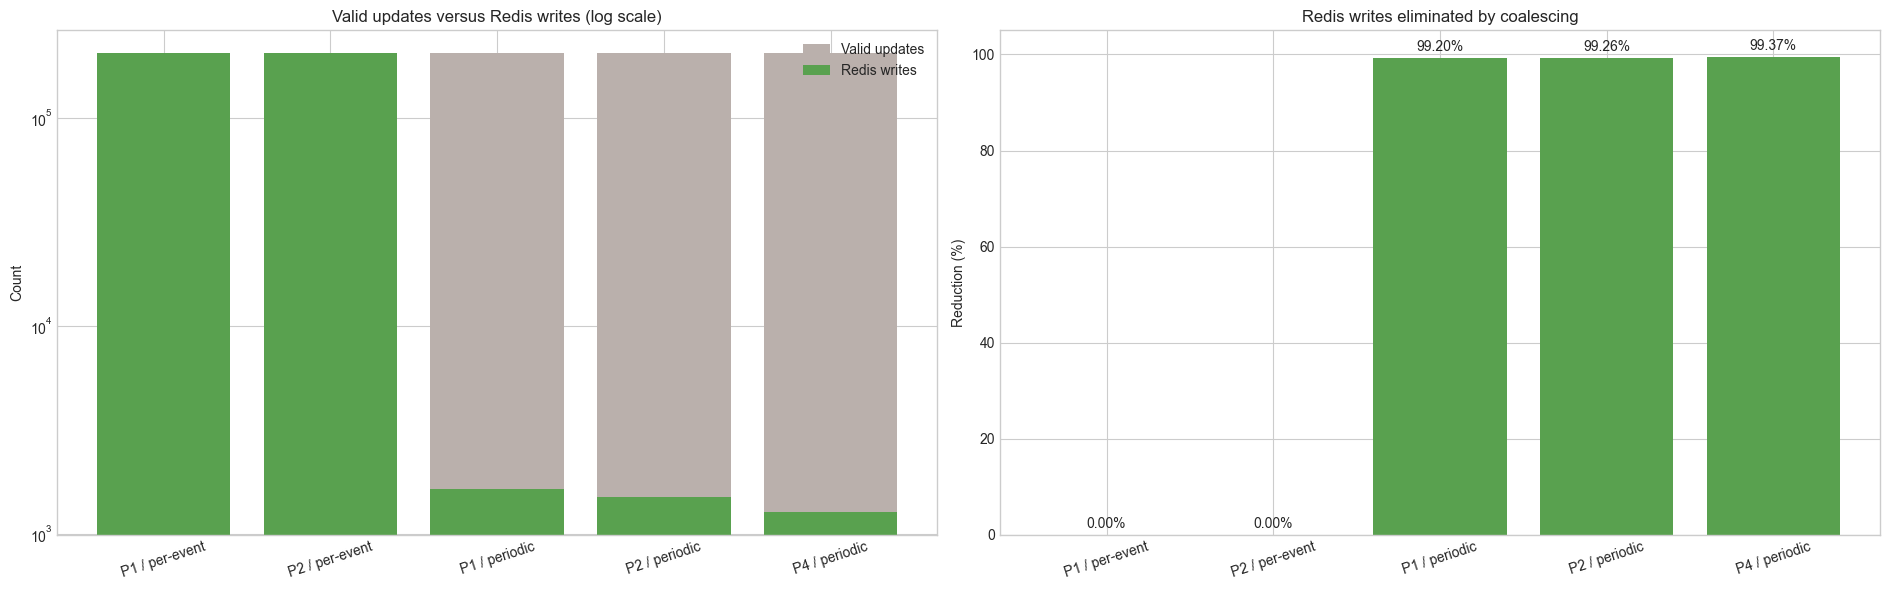

In [12]:
redis_table = summary[[
    "short_label",
    "valid_events",
    "redis_flushes",
    "redis_updates_flushed",
    "redis_updates_coalesced",
    "updates_per_redis_write",
    "redis_write_reduction_pct",
    "flush_metrics_source",
]].copy()
display(redis_table.style.format({
    "valid_events": "{:,.0f}",
    "redis_flushes": "{:,.0f}",
    "redis_updates_flushed": "{:,.0f}",
    "redis_updates_coalesced": "{:,.0f}",
    "updates_per_redis_write": "{:.1f}x",
    "redis_write_reduction_pct": "{:.2f}%",
}))

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
axes[0].bar(labels, summary["valid_events"], color="#BAB0AC", label="Valid updates")
axes[0].bar(labels, summary["redis_flushes"], color="#59A14F", label="Redis writes")
axes[0].set_yscale("log")
axes[0].set_title("Valid updates versus Redis writes (log scale)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend()
reduction_colors = ["#59A14F" if "periodic" in label.lower() else "#BAB0AC" for label in labels]
reduction_bars = axes[1].bar(labels, summary["redis_write_reduction_pct"], color=reduction_colors)
axes[1].bar_label(reduction_bars, labels=[f"{value:.2f}%" for value in summary["redis_write_reduction_pct"]], padding=3)
axes[1].set_ylim(0, 105)
axes[1].set_title("Redis writes eliminated by coalescing")
axes[1].set_ylabel("Reduction (%)")
axes[1].tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

## Correctness and completeness

Throughput is useful only if the pipeline preserves the workload. This table reconciles producer totals, Flink processor totals, dead letters, aggregate Redis count changes, flushed-update accounting, and experiment gates. `PASS` requires exact event and flush reconciliation, zero dead letters, and successful configured gates.

In [13]:
correctness = summary[[
    "short_label",
    "produced_events",
    "processed_events",
    "dead_letters",
    "redis_impression_delta",
    "redis_click_delta",
    "redis_updates_flushed",
    "gates_passed",
]].copy()
correctness["all_events_processed"] = correctness["produced_events"] == correctness["processed_events"]
correctness["all_updates_flushed"] = correctness["processed_events"] == correctness["redis_updates_flushed"]
correctness["status"] = np.where(
    correctness[["all_events_processed", "all_updates_flushed", "gates_passed"]].all(axis=1) & (correctness["dead_letters"] == 0),
    "PASS",
    "CHECK",
)
correctness.style.format({
    "produced_events": "{:,.0f}",
    "processed_events": "{:,.0f}",
    "redis_impression_delta": "{:,.0f}",
    "redis_click_delta": "{:,.0f}",
    "redis_updates_flushed": "{:,.0f}",
})

,short_label,produced_events,processed_events,dead_letters,redis_impression_delta,redis_click_delta,redis_updates_flushed,gates_passed,all_events_processed,all_updates_flushed,status
configuration,,,,,,,,,,,
P1 / per-event Redis,P1 / per-event,"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS
P2 / per-event Redis,P2 / per-event,"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS
P1 / periodic Redis,P1 / periodic,"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS
P2 / periodic Redis,P2 / periodic,"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS
P4 / periodic Redis,P4 / periodic,"204,126","204,126",0,"200,000","4,126","204,126",True,True,True,PASS


## Subtask distribution

The stacked bars show each subtask's final `processed_events` count. Similar shares indicate that Kafka partitioning and Flink `key_by` distribute the tested keys reasonably evenly. A large imbalance would limit the benefit of adding parallel subtasks.

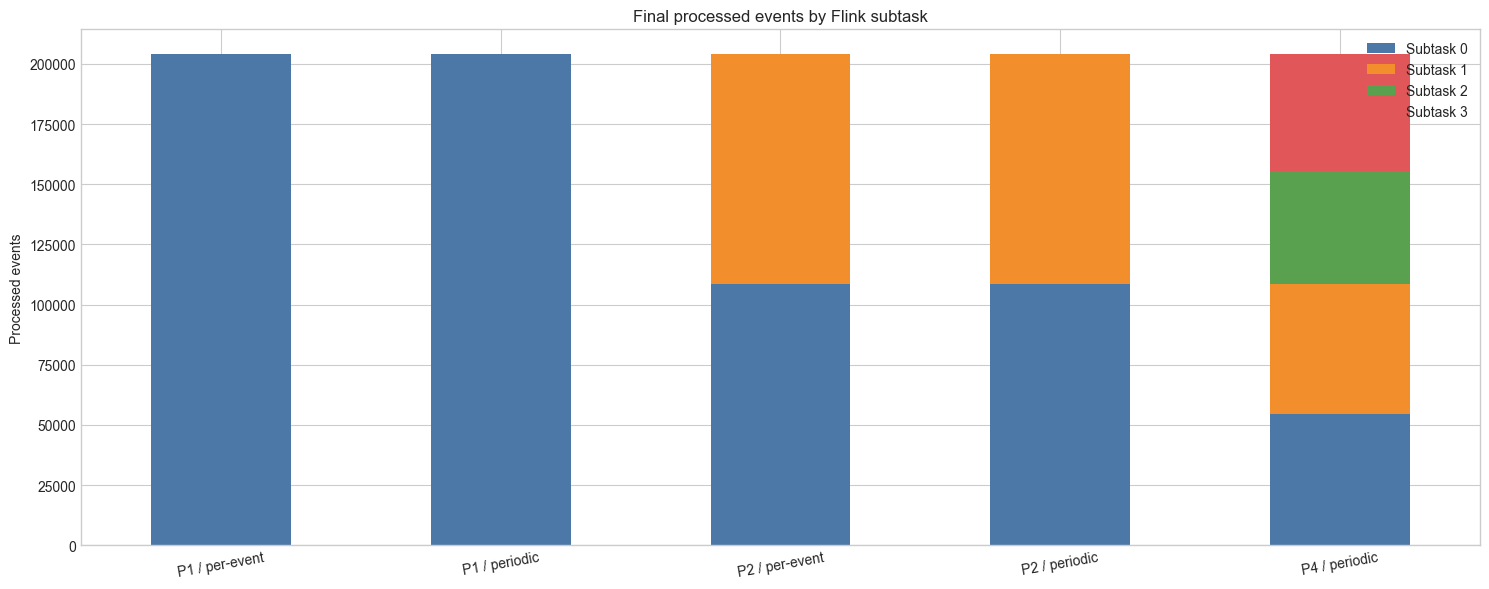

In [14]:
distribution_rows = []
for experiment in EXPERIMENTS:
    records = records_by_configuration[experiment["configuration"]]
    final_records = records.groupby("subtask_index", as_index=False).tail(1)
    for _, record in final_records.iterrows():
        distribution_rows.append({
            "short_label": experiment["short_label"],
            "subtask": f"Subtask {int(record['subtask_index'])}",
            "processed_events": int(record["processed_events"]),
        })
distribution = pd.DataFrame(distribution_rows).pivot(index="short_label", columns="subtask", values="processed_events").fillna(0)
ax = distribution.plot(kind="bar", stacked=True, figsize=(15, 6), color=["#4C78A8", "#F28E2B", "#59A14F", "#E15759"])
ax.set_title("Final processed events by Flink subtask")
ax.set_xlabel("")
ax.set_ylabel("Processed events")
ax.tick_params(axis="x", rotation=10)
ax.legend(title="")
plt.tight_layout()
plt.show()

## Conclusions

In [15]:
p1_per_event_result = summary.iloc[0]
p2_per_event_result = summary.iloc[1]
p1_periodic_result = summary.iloc[2]
p2_periodic_result = summary.iloc[3]
p4_periodic_result = summary.iloc[4]
display(Markdown(
    f"""
### Main findings

- With per-event Redis persistence, P2 achieves **{p2_per_event_result['full_window_eps'] / p1_per_event_result['full_window_eps']:.2f}x** the P1 full-window throughput (**{p1_per_event_result['full_window_eps']:,.0f}** versus **{p2_per_event_result['full_window_eps']:,.0f} events/sec**).
- At P2, periodic Redis persistence achieves **{p2_periodic_result['full_window_eps'] / p2_per_event_result['full_window_eps']:.2f}x** the per-event full-window throughput (**{p2_per_event_result['full_window_eps']:,.0f}** versus **{p2_periodic_result['full_window_eps']:,.0f} events/sec**).
- P2 periodic persistence uses **{int(p2_periodic_result['redis_flushes']):,}** Redis writes for **{int(p2_periodic_result['processed_events']):,}** valid updates, avoiding **{p2_periodic_result['redis_write_reduction_pct']:.2f}%** of per-event writes while preserving complete counts.
- At P1, periodic persistence achieves **{p1_periodic_result['full_window_eps'] / p1_per_event_result['full_window_eps']:.2f}x** the per-event full-window throughput (**{p1_per_event_result['full_window_eps']:,.0f}** versus **{p1_periodic_result['full_window_eps']:,.0f} events/sec**).
- With periodic persistence, P1, P2, and P4 measure **{p1_periodic_result['full_window_eps']:,.0f}**, **{p2_periodic_result['full_window_eps']:,.0f}**, and **{p4_periodic_result['full_window_eps']:,.0f} full-window events/sec**. P4 provides only a modest active-rate gain over P2 and does not improve end-to-end throughput.

### Interpretation

Synchronous per-event Redis writes are the dominant measured bottleneck. Flink keyed state with periodic persistence substantially increases throughput without losing event or Redis count completeness. Under periodic persistence, local scaling shows diminishing returns beyond P2: P2 has the best end-to-end result, while P4 has only a modest active-window advantage.
"""
))


### Main findings

- With per-event Redis persistence, P2 achieves **1.31x** the P1 full-window throughput (**3,652** versus **4,799 events/sec**).
- At P2, periodic Redis persistence achieves **3.68x** the per-event full-window throughput (**4,799** versus **17,651 events/sec**).
- P2 periodic persistence uses **1,515** Redis writes for **204,126** valid updates, avoiding **99.26%** of per-event writes while preserving complete counts.
- At P1, periodic persistence achieves **4.27x** the per-event full-window throughput (**3,652** versus **15,591 events/sec**).
- With periodic persistence, P1, P2, and P4 measure **15,591**, **17,651**, and **18,488 full-window events/sec**. P4 provides only a modest active-rate gain over P2 and does not improve end-to-end throughput.

### Interpretation

Synchronous per-event Redis writes are the dominant measured bottleneck. Flink keyed state with periodic persistence substantially increases throughput without losing event or Redis count completeness. Under periodic persistence, local scaling shows diminishing returns beyond P2: P2 has the best end-to-end result, while P4 has only a modest active-window advantage.


## Reproducibility and limitations

These measurements come from one local machine and one run per configuration. They establish a controlled baseline, but they do not quantify run-to-run variance, latency percentiles, CPU or memory saturation, Kafka consumer lag, network utilization, or Redis server utilization.

For stronger scalability claims, future experiments should add end-to-end event latency and resource-utilization metrics so throughput gains can be connected to their underlying cost.